# Baseline 模型：TF-IDF + Logistic Regression

使用 title 欄位做 TF-IDF 特徵，訓練 Logistic Regression 二元分類器，作為 XLM-RoBERTa 的比較基準。

## 路徑設定

In [1]:
from pathlib import Path

PROJECT_DIR   = Path("../")
PROCESSED_DIR = PROJECT_DIR / "dataset" / "processed"
MODEL_DIR     = PROJECT_DIR / "models" / "baseline"
RESULTS_DIR   = PROJECT_DIR / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

## 匯入套件

In [2]:
import platform
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import FeatureUnion

# 中文字體設定
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Microsoft JhengHei"
else:
    # Colab：先跑 !apt-get -q install fonts-noto-cjk 再重啟 runtime
    plt.rcParams["font.family"] = "Noto Sans CJK TC"
plt.rcParams["axes.unicode_minus"] = False  # 負號正常顯示

## 載入資料

In [3]:
import jieba

def tokenize(text, lang):
    if lang == "zh":
        return " ".join(jieba.cut(str(text)))
    return str(text)

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
valid_df = pd.read_csv(PROCESSED_DIR / "valid.csv")
test_df  = pd.read_csv(PROCESSED_DIR / "test.csv")

# train + valid 合併訓練，test 做最終評估
trainval_df = pd.concat([train_df, valid_df], ignore_index=True)

trainval_df["title_tok"] = [tokenize(t, l) for t, l in zip(trainval_df["title"], trainval_df["lang"])]
test_df["title_tok"]     = [tokenize(t, l) for t, l in zip(test_df["title"],     test_df["lang"])]

X_train = trainval_df["title_tok"]
y_train = trainval_df["label"]
X_test  = test_df["title_tok"]
y_test  = test_df["label"]

print(f"Train+Valid: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Label dist (train+valid): {y_train.value_counts().to_dict()}")
print("中文分詞範例:", trainval_df[trainval_df["lang"]=="zh"]["title_tok"].iloc[0])

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\tjx20\AppData\Local\Temp\jieba.cache
Loading model cost 2.156 seconds.
Prefix dict has been built successfully.


Train+Valid: 32,574 | Test: 3,620
Label dist (train+valid): {0: 17576, 1: 14998}
中文分詞範例: TFboys 遭 粉丝 激光 笔 攻击 ， 私生 饭 追星 有 多 猖狂 ？


## 訓練

In [4]:
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(analyzer="word",    ngram_range=(1, 3), 
                              max_features=80_000,
                              sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), 
                              max_features=80_000,
                              sublinear_tf=True,
                              min_df=2)),             # 過濾噪音
])


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
clf.fit(X_train_tfidf, y_train)

joblib.dump(vectorizer, MODEL_DIR / "tfidf_vectorizer.joblib")
joblib.dump(clf,        MODEL_DIR / "logistic_regression.joblib")
print("Model saved to", MODEL_DIR)

Model saved to ..\models\baseline


## 評估

In [5]:
y_pred = clf.predict(X_test_tfidf)

print("=== Test Set Results ===")
print(classification_report(y_test, y_pred, target_names=["non-clickbait", "clickbait"]))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

=== Test Set Results ===
               precision    recall  f1-score   support

non-clickbait       0.87      0.91      0.89      1953
    clickbait       0.89      0.85      0.87      1667

     accuracy                           0.88      3620
    macro avg       0.88      0.88      0.88      3620
 weighted avg       0.88      0.88      0.88      3620

Accuracy: 0.8801 | Macro F1: 0.8789


## 儲存評估結果

Metrics saved to: ..\results\baseline_metrics.csv
               precision  recall  f1-score    support
non-clickbait     0.8743  0.9083    0.8910  1953.0000
clickbait         0.8875  0.8470    0.8668  1667.0000
accuracy          0.8801  0.8801    0.8801     0.8801
macro avg         0.8809  0.8777    0.8789  3620.0000
weighted avg      0.8804  0.8801    0.8799  3620.0000


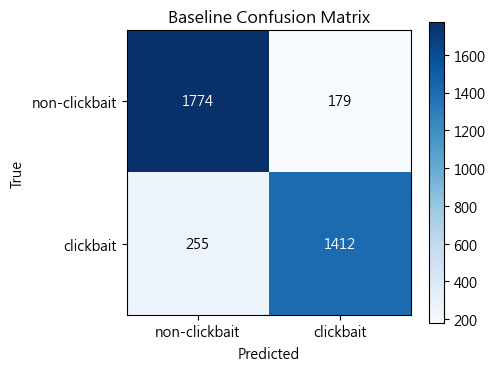

Confusion matrix saved to: ..\results\baseline_confusion_matrix.png


In [6]:
# --- Classification report → CSV ---
report_dict = classification_report(
    y_test, y_pred,
    target_names=["non-clickbait", "clickbait"],
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).transpose()
report_path = RESULTS_DIR / "baseline_metrics.csv"
report_df.to_csv(report_path, encoding="utf-8-sig")
print("Metrics saved to:", report_path)
print(report_df.round(4))

# --- Confusion matrix → PNG ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["non-clickbait", "clickbait"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["non-clickbait", "clickbait"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Baseline Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.tight_layout()
cm_path = RESULTS_DIR / "baseline_confusion_matrix.png"
fig.savefig(cm_path, dpi=150)
plt.show()
print("Confusion matrix saved to:", cm_path)

## 分語言評估

In [7]:
# 分語言評估：把預測結果和 test_df 的 lang 欄位對齊
eval_df = test_df[["lang", "label"]].copy()
eval_df["pred"] = y_pred

lang_map = {"en": "英文", "zh": "中文"}
rows = []

for lang, label in [("en", "英文"), ("zh", "中文")]:
    subset = eval_df[eval_df["lang"] == lang]
    acc = accuracy_score(subset["label"], subset["pred"])
    f1  = f1_score(subset["label"], subset["pred"], average="macro")
    rows.append({"語言": label, "Accuracy": round(acc, 4), "Macro F1": round(f1, 4)})
    print(f"{label}（{lang}）: Accuracy={acc:.4f} | Macro F1={f1:.4f}")
    print(classification_report(subset["label"], subset["pred"], target_names=["non-clickbait", "clickbait"]))

lang_df = pd.DataFrame(rows)
lang_df.to_csv(RESULTS_DIR / "baseline_metrics_by_lang.csv", index=False, encoding="utf-8-sig")
print("分語言結果已存至 results/baseline_metrics_by_lang.csv")

英文（en）: Accuracy=0.8357 | Macro F1=0.7484
               precision    recall  f1-score   support

non-clickbait       0.86      0.94      0.90      1480
    clickbait       0.73      0.51      0.60       474

     accuracy                           0.84      1954
    macro avg       0.79      0.72      0.75      1954
 weighted avg       0.83      0.84      0.82      1954

中文（zh）: Accuracy=0.9322 | Macro F1=0.9126
               precision    recall  f1-score   support

non-clickbait       0.95      0.81      0.87       473
    clickbait       0.93      0.98      0.95      1193

     accuracy                           0.93      1666
    macro avg       0.94      0.89      0.91      1666
 weighted avg       0.93      0.93      0.93      1666

分語言結果已存至 results/baseline_metrics_by_lang.csv


## 最具判斷力的特徵（TF-IDF 係數）

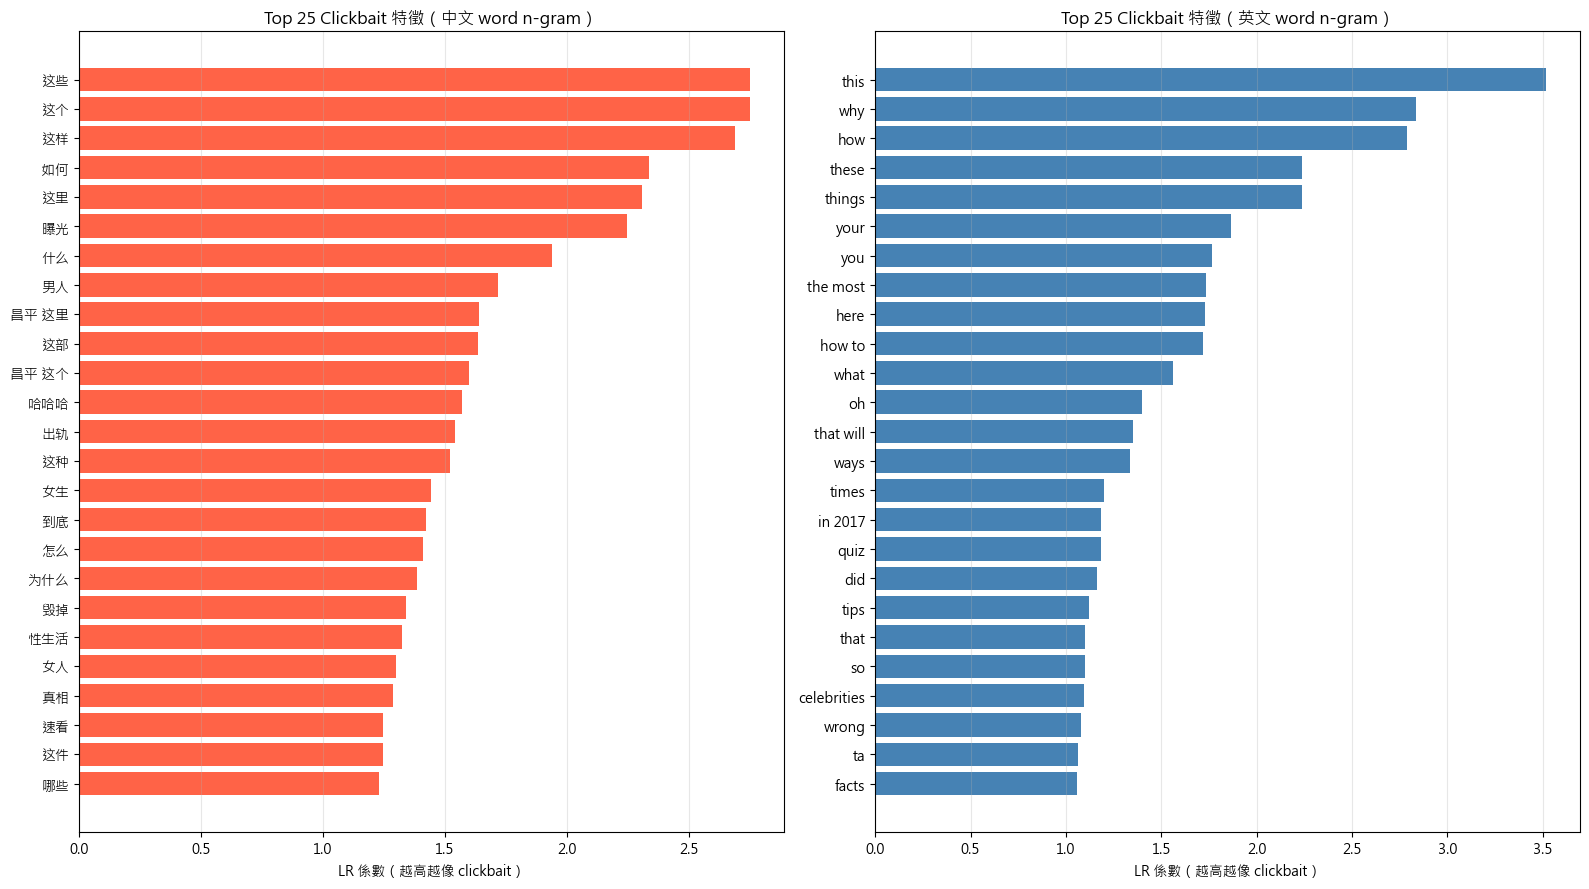

圖已存至 ..\results\baseline_top_features.png

=== Top 25 clickbait 特徵（中文）===
  '这些'                            coef=2.7504
  '这个'                            coef=2.7486
  '这样'                            coef=2.6877
  '如何'                            coef=2.3374
  '这里'                            coef=2.3064
  '曝光'                            coef=2.2482
  '什么'                            coef=1.9381
  '男人'                            coef=1.7187
  '昌平 这里'                         coef=1.6387
  '这部'                            coef=1.6372
  '昌平 这个'                         coef=1.5982
  '哈哈哈'                           coef=1.5685
  '出轨'                            coef=1.5423
  '这种'                            coef=1.5212
  '女生'                            coef=1.4421
  '到底'                            coef=1.4221
  '怎么'                            coef=1.4088
  '为什么'                           coef=1.3853
  '毁掉'                            coef=1.3406
  '性生活'                           coef=1.3256
  '女人'

In [8]:
import numpy as np

# 只取 word n-gram 的特徵名稱與係數（char n-gram 碎片不適合人工解讀）
word_vec = vectorizer.transformer_list[0][1]
n_word   = len(word_vec.get_feature_names_out())

word_feature_names = np.array(word_vec.get_feature_names_out())
word_coef          = clf.coef_[0][:n_word]
TOP_N = 25

def is_chinese(s):
    return any("一" <= c <= "鿿" for c in s)

def is_english(s):
    return all(c.isascii() for c in s) and not is_chinese(s)

def plot_top_features(ax, names, coefs, mask, title, color):
    indices = np.where(mask)[0]
    top_idx = indices[np.argsort(coefs[indices])[-TOP_N:][::-1]]
    labels_feat = [names[i] for i in top_idx]
    values      = [coefs[i] for i in top_idx]
    ax.barh(labels_feat[::-1], values[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("LR 係數（越高越像 clickbait）")
    ax.grid(axis="x", alpha=0.3)

zh_mask = np.array([is_chinese(f) for f in word_feature_names])
en_mask = np.array([is_english(f) for f in word_feature_names])

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plot_top_features(axes[0], word_feature_names, word_coef, zh_mask,
                  f"Top {TOP_N} Clickbait 特徵（中文 word n-gram）", "tomato")
plot_top_features(axes[1], word_feature_names, word_coef, en_mask,
                  f"Top {TOP_N} Clickbait 特徵（英文 word n-gram）", "steelblue")
fig.tight_layout()
feat_path = RESULTS_DIR / "baseline_top_features.png"
fig.savefig(feat_path, dpi=150)
plt.show()
print("圖已存至", feat_path)

# 印出數字
for lang, mask in [("中文", zh_mask), ("英文", en_mask)]:
    indices = np.where(mask)[0]
    top_idx = indices[np.argsort(word_coef[indices])[-TOP_N:][::-1]]
    print(f"\n=== Top {TOP_N} clickbait 特徵（{lang}）===")
    for i in top_idx:
        print(f"  {word_feature_names[i]!r:30s}  coef={word_coef[i]:.4f}")